In [1]:
from flappy_bird3 import Game
from flappy_bird3 import BaseModel
from Models import AutoEncoder
from ModifiedNEAT.util.datetime import eta, clock, unix_to_datetime_file
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as neat
import torch
import pygame
import math
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

from torch import Tensor
from torch.optim import lr_scheduler
from copy import deepcopy
from collections import deque

%matplotlib inline

C:\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
C:\Python\Python313\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(



UtilityError: Failed to load; Failed to load save folder; 'C:\Python\Python313\Lib\site-packages\Models\storage\autoencoders\flappy-bird\test\' does no exist
creating config
Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 515360
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0.0
weight_init_std           = 1.0
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_po

In [2]:
DEVICE = torch.device("gpu" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

In [3]:
class DataBuilder(object):
    def __init__(self, env: Game):
        self.env = env
        self.states: list[tuple[Tensor, bool]] = []

    def reset(self):
        self.states.clear()

    def collect(self, attempts: int):
        for attempts in range(attempts):
            states, _ = self.env.test()
            if len(states) > self.env.seq_len:
                self.states.extend([(s, t == len(states)-1) for t, s in enumerate(states[self.env.seq_len:])])
        self.env.window.close()

    def get(self, offset: int):
        if len(self.states) < 1 + offset:
            raise ValueError(f"Not enough states collected")
        current_states = []
        future_states = []
        states_hold: list[Tensor] = deque(maxlen=1+offset)
        index = 0
        for state, done in self.states:
            states_hold.append(state)
            if index >= offset:
                current_states.append(states_hold[0])
                future_states.append(states_hold[-1])
            index += 1
            if done:
                states_hold.clear()
                index = 0

        return tuple([torch.stack(g) for g in [current_states, future_states]])

In [4]:
MAX_SEQ_LEN = 16
A_OFFSET    = 0

In [5]:
from flappy_bird3 import FULL_STATES, SPAWN_WIDTH, GAP_SIZE, GAP_OFFSET

In [6]:
FULL_STATES = True
PIPE_Y_VELOCITY = 3
DELAY = 0

In [7]:
env = Game(
    1, goal=20, seq_len=MAX_SEQ_LEN,
    height=800, width=800, full_state=FULL_STATES, pipe_y_velocity=PIPE_Y_VELOCITY,
    spawn_width=SPAWN_WIDTH, tick=None, gap_offset=GAP_OFFSET, gap_size=GAP_SIZE,
    delay=0,
    device='cpu', dtype=DTYPE
)

In [8]:
env.birds.full_state

True

In [9]:
env.observation_space.shape

(1, 16, 7)

In [10]:
builder = DataBuilder(env)

In [11]:
builder.collect(10)

In [12]:
len(builder.states)

1061

In [13]:
env.offset, env.offset_select, env.buffer.shape

(0, tensor([], dtype=torch.int64), torch.Size([1, 16, 7]))

In [14]:
env.initialized = False
env.initialize()
env.reset()[0]
env.buffer
env.buffer[:, env.offset_select] = 0
env.buffer

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.3750, -0.0338, -0.2837,  ...,  0.6300,  0.4087,  0.2163]]])

In [15]:
pygame.display.quit()

In [16]:
states = builder.get(A_OFFSET)
states[0].shape

torch.Size([1061, 1, 16, 7])

In [17]:
states[0][:3, 0, -3:, -6:]

tensor([[[-0.0309, -0.2809,  0.3950,  0.5250,  0.3950,  0.2300],
         [-0.0581, -0.3081,  0.3875,  0.5175,  0.3950,  0.2300],
         [-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300]],

        [[-0.0581, -0.3081,  0.3875,  0.5175,  0.3950,  0.2300],
         [-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300],
         [-0.0997, -0.3497,  0.3725,  0.5025,  0.3950,  0.2300]],

        [[-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300],
         [-0.0997, -0.3497,  0.3725,  0.5025,  0.3950,  0.2300],
         [-0.0959, -0.3459,  0.3650,  0.4950,  0.3950,  0.2300]]])

In [18]:
states[1][:3, 0, -3:, -6:]

tensor([[[-0.0309, -0.2809,  0.3950,  0.5250,  0.3950,  0.2300],
         [-0.0581, -0.3081,  0.3875,  0.5175,  0.3950,  0.2300],
         [-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300]],

        [[-0.0581, -0.3081,  0.3875,  0.5175,  0.3950,  0.2300],
         [-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300],
         [-0.0997, -0.3497,  0.3725,  0.5025,  0.3950,  0.2300]],

        [[-0.0825, -0.3325,  0.3800,  0.5100,  0.3950,  0.2300],
         [-0.0997, -0.3497,  0.3725,  0.5025,  0.3950,  0.2300],
         [-0.0959, -0.3459,  0.3650,  0.4950,  0.3950,  0.2300]]])

In [19]:
def split_data(data: tuple[Tensor, ...], train_perc: float, device='cpu', dtype=torch.float32, max_count: int | None = None, delay: int | None = None):
    assert 1 > train_perc > 0
    if max_count is not None:
        assert max_count > 0
        max_count = min(len(data[0]), max_count)
        data = tuple([t[-max_count:] for t in data])
    input, output = data
    data_total = len(input)
    train_count = math.floor(data_total * train_perc)
    eval_count = data_total - train_count
    assert eval_count > 0
    datasets = []
    data_done = 0
    delay_indices = torch.arange(delay, device=device, dtype=torch.long) if delay is not None and delay > 0 else None
    for count in [train_count, eval_count]:
        chunk_input = input[data_done:data_done+count, 0]
        chunk_output = output[data_done:data_done+count, 0]
        if delay_indices is not None:
            delayed_input = chunk_input.clone()
            delayed_input[delay_indices] = 0.0
            chunk_input = torch.cat([chunk_input, delayed_input])
            chunk_output = torch.cat([chunk_output, chunk_output])
        dataset = (chunk_input.clone().to(device, dtype), chunk_output.clone().to(device, dtype))
        datasets.append(dataset)
        data_done += count
    return datasets

In [20]:
(train_inp, train_out), (eval_inp, eval_out) = split_data(states, 0.9, DEVICE, DTYPE, max_count=1000, delay=None)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

(torch.Size([900, 16, 7]),
 torch.Size([900, 16, 7]),
 torch.Size([100, 16, 7]),
 torch.Size([100, 16, 7]))

In [21]:
train_inp.device, train_inp.dtype

(device(type='cpu'), torch.float32)

In [22]:
torch.all(train_inp == train_out).cpu().item()

True

# Create autoencoder

In [51]:
A_INPUTS        = train_inp.shape[-1]
A_OUTPUTS       = 4
DIM_SIZE        = 32
KERNEL_SIZE     = 3
STRIDE          = 1
S_LAYERS        = 0
T_LAYERS        = 2
F_LAYERS        = 0
HEADS           = 1
KV_HEADS        = None
DIFFERENTIAL    = False
BIAS            = False
PROBABILISTIC   = True

ERROR! Session/line number was not unique in database. History logging moved to new session 10


In [52]:
SAVE_NAME = f"ae_ml{MAX_SEQ_LEN}-i{A_INPUTS}-o{A_OUTPUTS}-d{DIM_SIZE}-k{KERNEL_SIZE}-s{STRIDE}-"\
            f"sl{S_LAYERS}-tl{T_LAYERS}-fl{F_LAYERS}-h{HEADS}-kv{KV_HEADS}-"\
            f"diff{DIFFERENTIAL}-b{BIAS}-prob{PROBABILISTIC}-off{A_OFFSET}"

In [53]:
autoencoder = AutoEncoder(
    MAX_SEQ_LEN, A_INPUTS, DIM_SIZE, KERNEL_SIZE, S_LAYERS, T_LAYERS, F_LAYERS, HEADS, KV_HEADS,
    DIFFERENTIAL, BIAS, DEVICE, DTYPE,
    outputs=A_OUTPUTS, stride=STRIDE, probabilistic=PROBABILISTIC, out_bias=False,
)

In [54]:
autoencoder.load(SAVE_NAME, None, 'autoencoders', 'flappy-bird\\test', True)


UtilityError: Failed to load; Failed to load save folder; 'C:\Python\Python313\Lib\site-packages\Models\storage\autoencoders\flappy-bird\test\' does no exist


In [55]:
autoencoder

AutoEncoder(
  (encoder_embed): Sequential(
    (0): BufferEmbedding(
      (embedding): Linear(in_features=7, out_features=32, bias=True)
    )
    (1): BufferEncoding(
      (encoding): Embedding(16, 32)
    )
    (2): Transpose(dim0=-1, dim1=-2)
    (3): DownStream(
      (sequence): Sequential()
    )
    (4): Transpose(dim0=-1, dim1=-2)
  )
  (encoder_tx): TransformerBase(
    (layers): ModuleList(
      (0-1): 2 x TransformerBlock(
        (self_attention): Attention(
          *** residual=True, normalize=True, auto_single=False. causal_mask=True***
          (pre_norm): RMSNorm((32,), eps=1e-09, elementwise_affine=True)
          (query_proj): Linear(in_features=32, out_features=32, bias=False)
          (key_proj): Linear(in_features=32, out_features=32, bias=False)
          (value_proj): Linear(in_features=32, out_features=32, bias=False)
          (out_proj): Linear(in_features=32, out_features=32, bias=False)
          (rotary_embedding): RoPE()
          (softmax): Softma

In [56]:
test_inp = train_inp[:3]
test_out = train_out[:3]

In [57]:
with torch.no_grad():
    test_enc = autoencoder.encode(test_inp, verbose=2)
test_enc.shape


Executing Self Attention
Input => torch.Size([3, 16, 32])
Post Linearization =>
Query => torch.Size([3, 16, 32])
Key => torch.Size([3, 16, 32])
Value => torch.Size([3, 16, 32])
Q after Reshaping => torch.Size([3, 16, 1, 32])
K after Reshaping => torch.Size([3, 16, 1, 32])
Q after Rotary Embedding => torch.Size([3, 16, 1, 32])
K after Rotary Embedding => torch.Size([3, 16, 1, 32])
Duplicated K => torch.Size([3, 16, 1, 32])
Duplicated V => torch.Size([3, 16, 1, 32])
Energy => torch.Size([3, 1, 16, 16])
Mask => torch.Size([3, 1, 16, 16])
Masked Energy => torch.Size([3, 1, 16, 16])
Attention Score => torch.Size([3, 1, 16, 16])
Attented Values => torch.Size([3, 16, 32])
Output Projection => torch.Size([3, 16, 32])
TransformerBlock Output => torch.Size([3, 16, 32])

Executing Self Attention
Input => torch.Size([3, 16, 32])
Post Linearization =>
Query => torch.Size([3, 16, 32])
Key => torch.Size([3, 16, 32])
Value => torch.Size([3, 16, 32])
Q after Reshaping => torch.Size([3, 16, 1, 32])
K a

torch.Size([3, 16, 4])

In [58]:
with torch.no_grad():
    test_out_rev = autoencoder.decode(test_enc)
test_out_rev.shape

torch.Size([3, 16, 7])

In [59]:
test_out_rev = autoencoder.learn(test_inp).detach().cpu()

In [60]:
test_out_rev[:, -3:]

tensor([[[-1.7753, -0.6432, -1.2123,  ...,  2.0897, -0.8782,  0.1491],
         [ 2.6663,  0.9157,  0.7937,  ...,  0.0727, -1.4514,  1.1856],
         [ 2.6316, -0.5583, -0.6300,  ...,  2.6500,  0.0775, -1.5300]],

        [[-0.0385, -0.6763, -1.4434,  ...,  2.5377, -0.3396, -0.4321],
         [ 1.0935,  1.8017, -0.1656,  ...,  1.1442, -0.6718, -0.7297],
         [-0.4189, -1.1180, -0.5954,  ...,  4.7294, -0.3442, -0.5737]],

        [[-1.6313, -1.3650, -1.5575,  ...,  1.6091,  0.1464, -1.4969],
         [ 2.7355,  0.4842,  0.9235,  ...,  1.0596, -1.2296, -0.5143],
         [ 0.6513, -0.5237, -0.7270,  ...,  1.7705,  3.8087, -1.8227]]])

In [61]:
test_out[:, -3:]

tensor([[[ 0.4172,  0.0222, -0.2278,  ...,  0.0675,  0.3950,  0.2300],
         [ 0.4209,  0.0259, -0.2241,  ...,  0.0600,  0.3950,  0.2300],
         [ 0.4406,  0.1769, -0.0731,  ...,  0.4325,  0.2637,  0.3613]],

        [[ 0.4209,  0.0259, -0.2241,  ...,  0.0600,  0.3950,  0.2300],
         [ 0.4406,  0.1769, -0.0731,  ...,  0.4325,  0.2637,  0.3613],
         [ 0.4656,  0.2056, -0.0444,  ...,  0.4250,  0.2600,  0.3650]],

        [[ 0.4406,  0.1769, -0.0731,  ...,  0.4325,  0.2637,  0.3613],
         [ 0.4656,  0.2056, -0.0444,  ...,  0.4250,  0.2600,  0.3650],
         [ 0.4906,  0.2344, -0.0156,  ...,  0.4175,  0.2562,  0.3688]]])

In [62]:
with torch.no_grad():
    test_enc = autoencoder.encode(test_inp[:, -32:], single=False)
test_enc[:, :6, :4], test_enc.shape, test_inp.shape

(tensor([[[-0.9611,  0.8215, -0.7014, -1.6441],
          [-0.8154, -1.0975, -0.5651, -6.5666],
          [ 0.5308, -1.1087, -3.3287, -0.4009],
          [-0.8050,  0.9977, -2.5130, -6.4124],
          [-1.7024, -0.5114, -0.2696,  0.5949],
          [-0.3763, -1.8406, -1.3446, -2.6068]],
 
         [[ 0.1983, -0.4215, -2.5988, -1.7821],
          [-0.5057,  0.0893, -1.4129,  0.5980],
          [-2.3754, -0.6328, -0.9783, -0.1847],
          [-0.6147, -0.3895, -3.5825, -2.1114],
          [-0.1152,  0.8264, -1.9576,  0.3878],
          [-1.1168, -1.0285,  0.0149,  2.4642]],
 
         [[ 1.0641, -0.4471,  1.6804,  3.1873],
          [ 0.6269, -1.8106, -0.6112,  3.0051],
          [ 3.8182, -0.3220, -1.2474, -1.1994],
          [ 0.2281, -1.7749, -0.7170,  2.5936],
          [-0.3094,  0.3765, -3.0239,  1.3332],
          [-0.7730, -1.2867, -1.3397,  0.5338]]]),
 torch.Size([3, 16, 4]),
 torch.Size([3, 16, 7]))

# Train the model

In [63]:
torch.cuda.empty_cache()

In [64]:
def get_batches(count: int, batch_size: int, randomize=False):
    batch_total = math.ceil(count / batch_size)
    batch_indices = [
        list(range(i * batch_size, i * batch_size + min(batch_size, count - i * batch_size)))
        for i in range(batch_total)
    ]
    if randomize:
        random.shuffle(batch_indices)
        for batch in batch_indices:
            random.shuffle(batch)
    return batch_indices

In [65]:
def get_accuracy(model: AutoEncoder, inputs: Tensor, outputs: Tensor, error: float = 0.10, batches: int = None, epsilon=1e-4):
    torch.cuda.empty_cache()
    if batches is None:
        batches = len(inputs)
    if isinstance(batches, int):
        batches = get_batches(len(outputs), batches, False)
    elif isinstance(batches, list):
        pass
    else:
        raise NotImplemented(f"Batches must be an Integer or List of batch indices")

    with torch.no_grad():
        summation = 0
        for batch in batches:
            comp_out = model.learn(inputs[batch])
            target = outputs[batch] + epsilon
            total = torch.sum(
                ((target * (1 + error)) > comp_out) & (comp_out > (target * (1 - error)))
            ).cpu().item()
            summation += total
        accuracy = summation / outputs.numel()
    return accuracy

In [66]:
EVAL_BATCH_SIZE = 512

In [67]:
get_accuracy(autoencoder, eval_inp, eval_out, 0.1, EVAL_BATCH_SIZE), \
get_accuracy(autoencoder, train_inp, train_out, 0.1, EVAL_BATCH_SIZE)

(0.017142857142857144, 0.015188492063492064)

In [68]:
get_accuracy(autoencoder, eval_inp, eval_out, 0.5, EVAL_BATCH_SIZE), \
get_accuracy(autoencoder, train_inp, train_out, 0.5, EVAL_BATCH_SIZE)

(0.07526785714285714, 0.07196428571428572)

In [69]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0e-4
EPOCHS = 500

In [70]:
optimizer = optim.Adam(autoencoder.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer, 10)

In [71]:
def eta(time_start, units_done, units_total, text=''):
    time_done = clock.perf_counter() - time_start
    progress = round(units_done / units_total * 100)
    rem = round(time_done / units_done * (units_total - units_done))
    # print(f"\r{text}: progress={progress}% eta={rem}sec", end='')
    print(f"\reta={rem}s", end='')

In [72]:
# tts, tud, tut = clock.perf_counter(), 0, 5
# for _ in range(tut):
#     tud += 1
#     clock.sleep(1)
#     # time_done = clock.perf_counter() - tts
#     # progress = round(tud / tut * 100)
#     # rem = round(time_done / tud * (tut - tud))
#     # print(f"\r{'testing'}: progress={progress}% eta={rem}sec", end='')
#     eta(tts, tud, tut, f'testing {1}')

In [73]:
def plot_data(data: list[list[float]], labels: list[str], size=(14.4, 3.6)):
    axes = plt.subplots(1, len(data), figsize=size)[1]
    if len(data) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for axis, data, label in zip(axes, data, labels):
        if 'loss' in label.lower():
            data = np.log10(np.array(data))
        axis.plot(data)
        axis.set_title(label)
    plt.show()

In [74]:
def mse_loss(prediction: Tensor, target: Tensor, *, reduction='mean', dim: int | list[int] | None = None):
    loss = (target - prediction) ** 2
    if reduction == 'mean':
        loss = torch.mean(loss, dim=dim)
    elif reduction == 'sum':
        loss = torch.sum(loss, dim=dim)
    elif reduction == 'none':
        pass
    else:
        raise ValueError(f"Unsupported reduction '{reduction}'")
    return loss

def scale_loss(prediction: Tensor, target: Tensor, max_exponent: float | None = None, min_importance: float | None = None, reduce=True):
    assert prediction.ndim == 3
    if max_exponent is None:
        max_exponent = 10.0
    assert max_exponent >= 1.0
    if min_importance is None:
        min_importance = 0.01
    assert min_importance > 0.0
    loss = mse_loss(prediction, target, dim=(0, 2))
    seq_len = len(loss)
    if seq_len > 1:
        base = math.exp(math.log(max_exponent) / (seq_len - 1))
        # print(base)
        # print(base ** torch.arange(seq_len, device=loss.device, dtype=loss.dtype))
        bounds = 1 - min_importance
        importance = min_importance + bounds * ((base ** torch.arange(seq_len, device=loss.device, dtype=loss.dtype)) / max_exponent)
        # print(importance)
        loss = loss * importance
        # print(loss)
    if reduce:
        loss = torch.mean(loss)
    return loss

In [75]:
test_count = 10
test_tensor = (torch.arange(test_count) / (test_count-1) * 0.9 + 0.1).unsqueeze(0).unsqueeze(-1)
test_tensor[0, :, 0], scale_loss(torch.full_like(test_tensor, 1.0), torch.full_like(test_tensor, 0.0), max_exponent=100.0, reduce=False)

(tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
         1.0000]),
 tensor([0.0199, 0.0265, 0.0375, 0.0560, 0.0867, 0.1379, 0.2233, 0.3658, 0.6035,
         1.0000]))

In [76]:
def train(model: AutoEncoder, optimizer: optim.Optimizer, scheduler: lr_scheduler.LRScheduler, epochs: int, batch_size: int):
    torch.cuda.empty_cache()
    train_batches = get_batches(len(train_inp), batch_size, randomize=True)
    eval_batches = get_batches(len(eval_inp), batch_size, randomize=True)

    model.eval()
    with torch.no_grad():
        eval_loss = 0.0
        for batch in eval_batches:
            prediction = model.decode(model.encode(eval_inp[batch]))
            target = eval_out[batch]
            batch_loss = scale_loss(prediction, target)

            eval_loss += batch_loss.cpu().item()
        eval_loss /= len(train_batches)

    t_losses, e_losses = [], []
    t_accuracy, e_accuracy = [], []

    ts, ud, ut = clock.perf_counter(), 0, epochs
    best_loss, best_epoch = eval_loss, -1
    save_state = tuple([deepcopy(obj.state_dict()) for obj in [model, optimizer, scheduler]])
    try:
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for batch in train_batches:
                # target = train_out[batch]
                # target = target if not REDUCED else target[:, -1]
                # encoding = autoencoder.encode(train_inp[batch])
                # decoding0, decoding1 = autoencoder.decode(encoding, type=2, single=REDUCED)
                prediction = model.decode(model.encode(train_inp[batch]))
                # prediction = autoencoder.learn(train_inp[batch])
                # batch_loss0 = scale_loss(decoding0, target)
                # if not REDUCED:
                #     # batch_loss1 = scale_loss(decoding1[:, 1:], encoding[:, :-1])
                #     batch_loss1 = scale_loss(decoding1, encoding)
                # else:
                #     batch_loss1 = scale_loss(decoding1, encoding[:, -1])
                # batch_loss = batch_loss0 + batch_loss1
                target = train_out[batch]
                batch_loss = scale_loss(prediction, target)
                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()

                train_loss += batch_loss.cpu().item()
            train_loss /= len(train_batches)
            train_acc = get_accuracy(model, train_inp, train_out, 0.03, train_batches)

            scheduler.step()

            model.eval()
            with torch.no_grad():
                eval_loss = 0.0
                for batch in eval_batches:
                    prediction = model.decode(model.encode(eval_inp[batch]))
                    target = eval_out[batch]
                    batch_loss = scale_loss(prediction, target)

                    eval_loss += batch_loss.cpu().item()
                eval_loss /= len(train_batches)
                eval_acc = get_accuracy(model, eval_inp, eval_out, 0.03, eval_batches)

            if eval_loss < best_loss:
                best_loss = eval_loss
                best_epoch = epoch
                save_state = tuple([deepcopy(obj.state_dict()) for obj in [model, optimizer, scheduler]])

            t_losses.append(train_loss)
            e_losses.append(eval_loss)
            t_accuracy.append(train_acc)
            e_accuracy.append(eval_acc)

            ud += 1
            eta(ts, ud, ut, f"Training model: train_loss={train_loss:.4e}, eval_loss={eval_loss:.4e}, "
                            f"train_acc={train_acc*100:.2f}%, eval_acc={eval_acc*100:.2f}%, be={best_epoch}")
    except KeyboardInterrupt:
        pass
    optimizer.zero_grad()
    for ss, obj in zip(save_state, [model, optimizer, scheduler]):
        obj.load_state_dict(ss)
    print(f"\nCompleted training in {clock.perf_counter() - ts:.2f} s. Loaded epoch {best_epoch}")

    torch.cuda.empty_cache()
    model.eval()
    plot_data([t_losses, e_losses, t_accuracy, e_accuracy],
              ['Train Loss', 'Eval Loss', 'Train Accuracy', 'Eval Accuracy'])
    return t_losses, e_losses, t_accuracy, e_accuracy

In [77]:
TRAIN_BATCH_SIZE = 256

eta=0sss
Completed training in 148.07 s. Loaded epoch 454


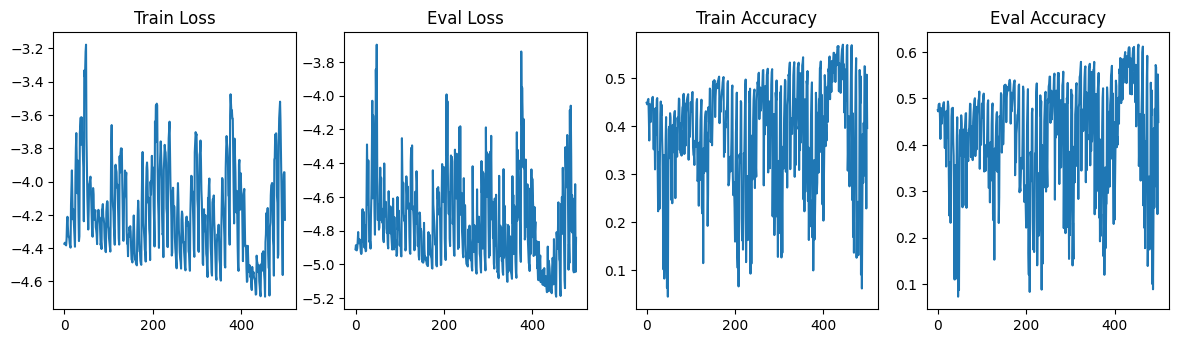

In [110]:
train_data = train(autoencoder, optimizer, scheduler, EPOCHS, TRAIN_BATCH_SIZE)

eta=0sss
Completed training in 191.33 s. Loaded epoch 496


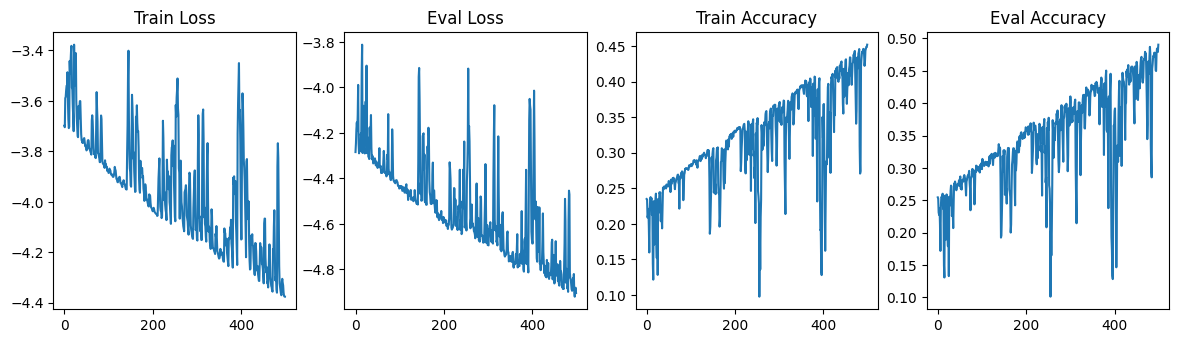

In [79]:
train_data = train(autoencoder, optimizer, scheduler, EPOCHS*1, TRAIN_BATCH_SIZE)

# Evaluate

In [111]:
def sample_batch(*tensors: Tensor, n: int) -> tuple[Tensor, ...]:
    """
    Randomly sample n unique indices from the first dimension of a tensor.

    Args:
        tensor (torch.Tensor): Input tensor of shape (batch_size, ...).
        n (int): Number of samples to draw.

    Returns:
        torch.Tensor: Tensor subset with n unique rows.
    """
    assert len(tensors) > 0
    assert tensors[0].size(0) > 0
    batch_size = tensors[0].size(0)
    indices = torch.randperm(batch_size)[:n]  # unique, random order
    return tuple([t[indices] for t in tensors])

In [112]:
get_accuracy(autoencoder, eval_inp, eval_out, 0.1, EVAL_BATCH_SIZE), \
get_accuracy(autoencoder, train_inp, train_out, 0.1, EVAL_BATCH_SIZE)

(0.8047321428571429, 0.7654166666666666)

In [113]:
get_accuracy(autoencoder, eval_inp, eval_out, 0.5, EVAL_BATCH_SIZE), \
get_accuracy(autoencoder, train_inp, train_out, 0.5, EVAL_BATCH_SIZE)

(0.8654464285714286, 0.813968253968254)

In [114]:
get_accuracy(autoencoder, eval_inp, eval_out, 0.03, EVAL_BATCH_SIZE), \
get_accuracy(autoencoder, train_inp, train_out, 0.03, EVAL_BATCH_SIZE)

(0.614375, 0.5685912698412698)

In [115]:
test_inp, test_out = sample_batch(eval_inp, eval_out, n=3)

In [116]:
with torch.no_grad():
    test_out_rev = torch.round(autoencoder.decode(autoencoder.encode(test_inp), single=True).detach().cpu(), decimals=4)
test_out_rev[:].float()

tensor([[ 0.5398,  0.4668,  0.2134,  ...,  0.2269,  0.0675,  0.5668],
        [ 0.2802,  0.0298, -0.2235,  ...,  0.1980,  0.2441,  0.3725],
        [ 0.3821,  0.0405, -0.2076,  ...,  0.3360,  0.3346,  0.2909]])

In [117]:
with torch.no_grad():
    test_out_rev = torch.round(autoencoder.learn(test_inp).detach().cpu(), decimals=4)
test_out_rev[:, -4:]

tensor([[[ 0.4543,  0.4040,  0.1484,  ...,  0.2641,  0.0567,  0.5586],
         [ 0.4875,  0.4157,  0.1717,  ...,  0.2560,  0.0645,  0.5767],
         [ 0.5075,  0.4521,  0.1882,  ...,  0.2429,  0.0681,  0.5575],
         [ 0.5377,  0.4621,  0.2196,  ...,  0.2312,  0.0510,  0.5716]],

        [[ 0.3473,  0.0870, -0.1639,  ...,  0.2184,  0.2553,  0.3634],
         [ 0.3375,  0.0799, -0.1746,  ...,  0.2094,  0.2588,  0.3750],
         [ 0.3024,  0.0473, -0.1927,  ...,  0.2032,  0.2594,  0.3754],
         [ 0.2862,  0.0303, -0.2257,  ...,  0.1962,  0.2550,  0.3667]],

        [[ 0.3773,  0.0343, -0.2093,  ...,  0.3539,  0.3341,  0.2913],
         [ 0.3618,  0.0261, -0.2311,  ...,  0.3367,  0.3392,  0.2914],
         [ 0.3612,  0.0322, -0.2150,  ...,  0.3340,  0.3364,  0.2926],
         [ 0.3844,  0.0437, -0.2099,  ...,  0.3412,  0.3361,  0.2887]]])

In [118]:
test_out[:, -4:]

tensor([[[ 0.4625,  0.4075,  0.1575,  ...,  0.2525,  0.0550,  0.5700],
         [ 0.4875,  0.4325,  0.1825,  ...,  0.2450,  0.0550,  0.5700],
         [ 0.5125,  0.4575,  0.2075,  ...,  0.2375,  0.0550,  0.5700],
         [ 0.5375,  0.4825,  0.2325,  ...,  0.2300,  0.0550,  0.5700]],

        [[ 0.3522,  0.0897, -0.1603,  ...,  0.2175,  0.2625,  0.3625],
         [ 0.3325,  0.0737, -0.1762,  ...,  0.2100,  0.2587,  0.3663],
         [ 0.3069,  0.0519, -0.1981,  ...,  0.2025,  0.2550,  0.3700],
         [ 0.2797,  0.0284, -0.2216,  ...,  0.1950,  0.2512,  0.3738]],

        [[ 0.3803,  0.0453, -0.2047,  ...,  0.3525,  0.3350,  0.2900],
         [ 0.3631,  0.0281, -0.2219,  ...,  0.3450,  0.3350,  0.2900],
         [ 0.3669,  0.0319, -0.2181,  ...,  0.3375,  0.3350,  0.2900],
         [ 0.3866,  0.0516, -0.1984,  ...,  0.3300,  0.3350,  0.2900]]])

In [119]:
with torch.no_grad():
    test_enc = autoencoder.encode(test_inp, single=True).float()

test_enc[:], test_enc.shape, test_inp.shape

(tensor([[ 0.6613, -0.4737,  1.4499, -0.9135],
         [ 0.0458,  0.1286, -0.9434, -0.5608],
         [-0.5449,  0.6018, -0.9335, -1.1521]]),
 torch.Size([3, 4]),
 torch.Size([3, 16, 7]))

In [120]:
eval_out[:, :, -2:].shape

torch.Size([100, 16, 2])

In [121]:
mask = (eval_out[:, :, -1:] != 1).any(dim=(1, 2))
mask

tensor([True, True, True,  ..., True, True, True])

In [122]:
indices = torch.nonzero(mask, as_tuple=True)[0]
indices

tensor([ 0,  1,  2,  ..., 97, 98, 99])

In [123]:
eval_out[indices, :, -1:]

tensor([[[0.2950],
         [0.2988],
         [0.3025],
         ...,
         [0.3438],
         [0.3475],
         [0.3512]],

        [[0.2988],
         [0.3025],
         [0.3063],
         ...,
         [0.3475],
         [0.3512],
         [0.3550]],

        [[0.3025],
         [0.3063],
         [0.3100],
         ...,
         [0.3512],
         [0.3550],
         [0.3587]],

        ...,

        [[0.5700],
         [0.5700],
         [0.5700],
         ...,
         [0.5700],
         [0.5700],
         [0.5700]],

        [[0.5700],
         [0.5700],
         [0.5700],
         ...,
         [0.5700],
         [0.5700],
         [0.5700]],

        [[0.5700],
         [0.5700],
         [0.5700],
         ...,
         [0.5700],
         [0.5700],
         [0.5700]]])

# View Attention

In [124]:
def plot_attention(inputs: Tensor, type: int, layer_index: int | None = None, size=(1440, 1080), inverse=False,
                   cmap='bone_r', crop=1, exg=1, single=False, force_line=False):
    assert inputs.ndim == 2
    plt.close()

    # Calculate attention
    with torch.no_grad():
        res = autoencoder.encode(inputs, get=True, single=single and type == 0)
        if type == 1:
            autoencoder.decode(res, get=True, single=single and type == 1).cpu()
        tx_base = autoencoder.encoder_tx if type == 0 else autoencoder.decoder_tx

    # Get layers self attention
    self_attention = [l[0].to('cpu', torch.float64) for l in tx_base.get_attention()]
    if layer_index is not None:
        self_attention = self_attention[[layer_index]]
    # if layer_index is not None:
    #     self_attention = self_attention[layer_index].to('cpu', torch.float64)
    # else:
    #     self_attention = torch.mean(torch.stack(self_attention), dim=0).to('cpu', torch.float64)
    b, heads, q, k = self_attention[0].shape
    rows = heads
    columns = len(self_attention) if layer_index is None else 1
    # print(rows, columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[0] * 0.01, size[1] * 0.01))
    # fig.patch.set_facecolor(bg)
    if not isinstance(axes, np.ndarray):
        axes = np.array([[axes]])
    else:
        if rows == 1:
            axes = np.expand_dims(axes, 0)
        if columns == 1:
            axes = np.expand_dims(axes, 1)
    if inverse:
        axes = axes.transpose()
    # print(axes.shape)
    x = 0
    for li, attention in enumerate(self_attention):
        for hi, att_head in enumerate(attention[0]):
            title = f"L{li if layer_index is None else layer_index} H{hi}"
            if force_line:
                att_head = att_head[[-1]]
            q, k = att_head.shape[-2:]
            # print(q, k)
            if q != 1:
                # att_head = att_head.expand(k, k)
                # q = k
                if exg is not None:
                    att_head = torch.clamp(att_head * exg, 0, 1)
                if crop is not None:
                    k_red = k // crop
                    k_max = max(1, k // 2 - k_red)
                    k_idx = np.random.randint(k_max)
                    k_ind = torch.arange(k_idx, k_idx + k_red).to(att_head.device)
                    q_red = min(q, q // crop)
                    q_max = max(1, q // 2 - q_red)
                    q_idx = np.random.randint(q_max)
                    q_ind = torch.arange(q_idx, q_idx + q_red).to(att_head.device)
                    # print(q_ind, k_ind, att_head.shape)
                    # print(att_head.shape, q_ind.shape, k_ind.shape, q, k)
                    att_head = torch.index_select(torch.index_select(att_head, 0, q_ind), 1, k_ind)
                    # print(att_head.shape)
                axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            else:
                axes[hi, li].plot(att_head.squeeze(0))
            axes[hi, li].set_title(title)
            x += 1
    plt.show()

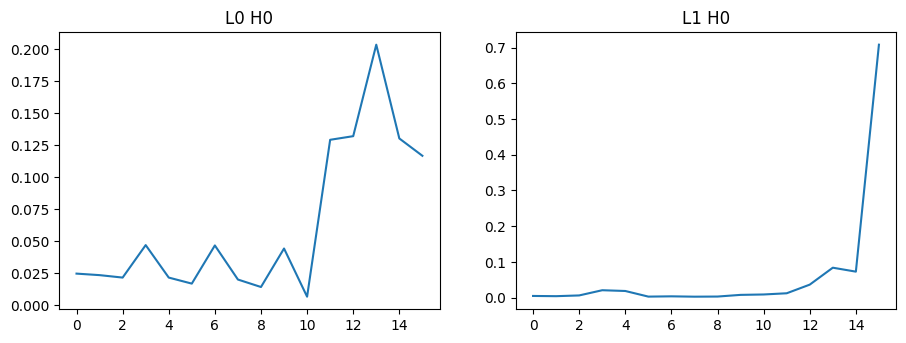

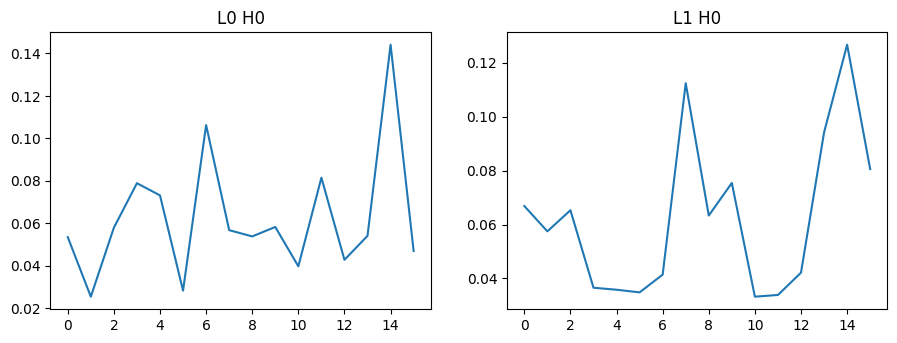

In [125]:
sample_input = sample_batch(eval_inp, n=1)[0][0]
# sample_input.shape
plot_attention(sample_input, type=0, layer_index=None, size=(1080, 360), crop=1, exg=10, single=True, force_line=True)
plot_attention(sample_input, type=1, layer_index=None, size=(1080, 360), crop=1, exg=10, single=True, force_line=True)

# Save model

In [126]:
autoencoder.save(SAVE_NAME, None, 'autoencoders', 'flappy-bird\\test', True)

Successfully dumped AutoEncoder Model save file to 'C:\Python\Python313\Lib\site-packages\Models\storage\autoencoders\flappy-bird\test\ae_ml16-i7-o4-d32-k3-s1-sl0-tl2-fl0-h1-kvNone-diffFalse-bFalse-probTrue-off0-2.pkl'.


In [127]:
(torch.randn((100, 300, 2, 1, 8)) @ torch.randn(100, 1, 2, 8, 4)).shape

torch.Size([100, 300, 2, 1, 4])

In [128]:
(torch.randn((3, 4)) @ torch.randn(3, 4, 4)).shape

torch.Size([3, 3, 4])

In [129]:
test_shape = (2, 1, 4)
test_tensor = torch.arange(math.prod(test_shape)).view(test_shape).unsqueeze(-1)
test_exp = torch.arange(3)
test_res = test_tensor ** test_exp
test_tensor, test_res, test_tensor.shape, test_res.shape

(tensor([[[[0],
           [1],
           [2],
           [3]]],
 
 
         [[[4],
           [5],
           [6],
           [7]]]]),
 tensor([[[[ 1,  0,  0],
           [ 1,  1,  1],
           [ 1,  2,  4],
           [ 1,  3,  9]]],
 
 
         [[[ 1,  4, 16],
           [ 1,  5, 25],
           [ 1,  6, 36],
           [ 1,  7, 49]]]]),
 torch.Size([2, 1, 4, 1]),
 torch.Size([2, 1, 4, 3]))

# Create NEAT setup

In [71]:
def fix(value: float, default: float = 1):
    if np.isinf(value) or np.isnan(value):
        return default
    else:
        return value

# Architecture
GENOMES             = 100
# MAX_SEQ_LEN         = 16
# SEQ_MULT            = 8
SEQ_LEN             = MAX_SEQ_LEN // 1
FULL_STATES         = True
INPUTS              = A_OUTPUTS # SEQ_LEN // (STRIDE ** S_LAYERS) * A_OUTPUTS # 3 if not FULL_STATES else 5
OUTPUTS             = 1
EMBED_SIZE          = 16
LAYERS              = 3
ENABLE_BIAS         = True
PROBABILISTIC       = False
MEMORY_SIZE         = 5
GAMMA               = np.exp(np.log(0.33) / 128)
ALPHA               = fix(np.exp(np.log(1.10) / (MEMORY_SIZE - 1)), 1.0)
ALPHA_ORDER         = 4
REW_NORM            = 2
LOSS_REG            = 0.
ACTIVATION          = nn.Tanh()
CLIP_MIN            = -4
CLIP_MAX            = -0
DISTRIBUTION        = 'mult_var_normal'

In [72]:
MODEL0 = BaseModel(INPUTS, OUTPUTS, EMBED_SIZE, LAYERS, 1, ACTIVATION, PROBABILISTIC, ENABLE_BIAS, DEVICE, DTYPE, clip_min=CLIP_MIN, clip_max=CLIP_MAX, distribution=DISTRIBUTION)
MODEL1 = BaseModel(INPUTS, OUTPUTS, EMBED_SIZE, LAYERS, 1, nn.ReLU(), PROBABILISTIC, ENABLE_BIAS, DEVICE, DTYPE, clip_min=CLIP_MIN, clip_max=CLIP_MAX, distribution=DISTRIBUTION)
MODEL2 = BaseModel(INPUTS, OUTPUTS, EMBED_SIZE, LAYERS, 1, nn.SiLU(), PROBABILISTIC, ENABLE_BIAS, DEVICE, DTYPE, clip_min=CLIP_MIN, clip_max=CLIP_MAX, distribution=DISTRIBUTION)

In [73]:
config = neat.Config()

config.genome.init_type                     = 'normal'
config.genome.weight_init_mean              = 0.0
config.genome.weight_init_std               = 1.0
config.genome.weight_min_value              = -np.inf
config.genome.weight_max_value              = +np.inf
config.genome.weight_mutate_power           = 3e-1
config.genome.weight_mutate_rate            = 0.50
config.genome.weight_replace_rate           = 0.00
config.genome.weight_add_prob               = 0.00
config.genome.weight_del_prob               = 0.00
config.genome.single_structural_mutation    = False

config.reproduction.min_species_size        = GENOMES
config.reproduction.purge                   = 1
config.reproduction.clone_threshold         = 0.05
config.reproduction.survival_threshold      = 0.20
config.reproduction.cross_threshold         = 0.00
config.reproduction.elitism                 = 30
config.species.compatibility_threshold      = np.inf
config.stagnation.max_stagnation            = 1
config.stagnation.species_elitism           = 2
config.reproduction.darwin_multiplier       = 0.30
config.reproduction.cross_multiplier        = 0.90
config.reproduction.preserve_elite          = False
config.save()
config.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 515700
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0.0
weight_init_std           = 1.0
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.3
weight_mutate_rate        = 0.5
weight_replace_rate       = 0.0
weight_add_prob           = 0.0
weight_del_prob           = 0.0
compatibility_disjoint_coeffici

In [74]:
population = neat.Population(GENOMES, MODEL0, config, init_reporter=True)
population1 = neat.Population(GENOMES, MODEL1, config, init_reporter=True)
population2 = neat.Population(GENOMES, MODEL2, config, init_reporter=True)
population.absorb_population(population1)
population.absorb_population(population2)

Initialized genomes in  in 0.51s
Ran distance kernel in 0.11 s
Created distances cache in 1.51 s
Collected species representatives in 2.71 s
Filled species in 1.55 s
Updated species mapping in 0.96 s
Completed speciating in 6.73 s
Mean genetic distance 0.092, standard deviation 0.043, with 1 species
Initialized genomes in  in 0.18s
Ran distance kernel in 0.01 s
Created distances cache in 0.16 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.16 s
Mean genetic distance 0.092, standard deviation 0.042, with 1 species
Initialized genomes in  in 0.16s
Ran distance kernel in 0.01 s
Created distances cache in 0.16 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.16 s
Mean genetic distance 0.102, standard deviation 0.050, with 1 species


In [75]:
INIT_GEN: int = None

RUNS = 1
GOAL = 20
STEPS = GOAL * 100 * RUNS
EPOCHS = 100

# Test on NEAT

In [76]:
import warnings

warnings.filterwarnings(action='ignore', category=RuntimeWarning)

In [77]:
MODEL0

BaseModel(
  probabilistic=False, distro='mult_var_normal'
  (projection): Sequential[NeatModule](
    (0): Linear[NeatModule](inputs=4, outputs=16, bias=True)
    (1): Tanh()
    (2): Linear[NeatModule](inputs=16, outputs=16, bias=True)
    (3): Tanh()
    (4): Linear[NeatModule](inputs=16, outputs=16, bias=True)
    (5): Tanh()
    (6): Linear[NeatModule](inputs=16, outputs=16, bias=True)
  )
  (pol_proj): Sequential[NeatModule](
    (0): Tanh()
    (1): Linear[NeatModule](inputs=16, outputs=2, bias=True)
  )
)

In [78]:
autoencoder(torch.tensor(env.observation_space.sample(), device=DEVICE, dtype=DTYPE)).shape

torch.Size([1, 4])

In [79]:
def evaluate(population: neat.Population, **options):
    trainer: neat.rl.NEAT = options['trainer']
    mapping0, mapping1, mapping2 = population.get_mapping()
    cons_mapping = population.get_mapping(consolidated=True)
    trainer.update_mapping(cons_mapping)
    # BUFFER = torch.zeros(SEQ_LEN, population.pop_size, INPUTS).to(DEVICE, DTYPE)
    global INIT_GEN
    if INIT_GEN is None:
        INIT_GEN = population.generation

    for genome in population.genomes.values():
        genome.fitness = 0

    terminate = False
    start = 0
    run_step = 0
    game_step = 0
    DEBUG = True
    DEBUG_STEP = 0
    MODEL0.train()
    while not terminate:
        env = Game(
            population.size, goal=GOAL, seq_len=SEQ_LEN,
            height=800, width=800, full_state=FULL_STATES,
            spawn_width=SPAWN_WIDTH, tick=None, gap_offset=GAP_OFFSET, gap_size=GAP_SIZE,
            type2count=len(mapping2), type2offset=0, device=DEVICE, dtype=DTYPE
        )
        # print(f"Anti Count = {game.birds.}")

        gts = clock.perf_counter()
        step = 0
        reverse_mapping0 = {index: key for key, index in mapping0.items()}
        reverse_mapping1 = {index: key for key, index in mapping1.items()}
        reverse_mapping2 = {index: key for key, index in mapping2.items()}

        states = env.reset()[0]
        done = False
        while not done:
            with torch.no_grad():
                # Get Inputs ~ send bird location, top pipe location and bottom pipe location
                # and determine from network whether to jump or not
                states = autoencoder(states.to(DEVICE, DTYPE))
                if DEBUG and population.generation == INIT_GEN and step == DEBUG_STEP:
                    print(f"\nobservations =>\n{states}\n\tshape = {states.shape}")

                # Filter dead birds from calculation
                ts = clock.perf_counter()
                keys0, keys1, keys2 = [], [], []
                indices0, indices1, indices2 = [], [], []
                for index, dead in enumerate(env.birds.dead):
                    if not dead:
                        if index in reverse_mapping0:
                            keys0.append(reverse_mapping0[index])
                            indices0.append(index)
                        elif index-len(mapping0) in reverse_mapping1:
                            keys1.append(reverse_mapping1[index-len(mapping0)])
                            indices1.append(index-len(mapping0))
                        elif index-(len(mapping0)+len(mapping1)) in reverse_mapping2:
                            keys2.append(reverse_mapping2[index-(len(mapping0)+len(mapping1))])
                            indices2.append(index-(len(mapping0)+len(mapping1)))
                        else:
                            print(f"\nPopulation size {population.size}"
                                  f"\nReverse mapping \n{reverse_mapping0} \n{reverse_mapping1}"
                                  f"\nIndex = {index}, birds_shape = {env.birds.dead.shape}")
                            raise KeyError()
                if len(indices0) == 0:
                    keys0 = list(mapping0.keys())
                    indices0 = list(mapping0.values())
                if len(indices1) == 0:
                    keys1 = list(mapping1.keys())
                    indices1 = list(mapping1.values())
                if len(indices2) == 0:
                    keys2 = list(mapping2.keys())
                    indices2 = list(mapping2.values())
                if DEBUG and population.generation == INIT_GEN and step == DEBUG_STEP:
                    print(f"keys =>\n{keys0}")
                    print(f"indices =>\n{indices0}")

                # Get actions
                observations0, observations1, observations2 = torch.split(
                    states, [len(mapping0), len(mapping1), len(mapping2)], dim=0
                )
                actions0, probs = MODEL0.get_action(observations0[indices0].unsqueeze(1), keys=keys0)
                actions1, probs = MODEL1.get_action(observations1[indices1].unsqueeze(1), keys=keys1)
                actions2, probs = MODEL2.get_action(observations2[indices2].unsqueeze(1), keys=keys2)
                # shape(seq_len=1, genomes, features_out)
                actions0, actions1, actions2, probs = actions0.squeeze(1), actions1.squeeze(1), actions2.squeeze(1), probs.squeeze(1)
                if DEBUG and population.generation == INIT_GEN and step == DEBUG_STEP:
                    MODEL0.get_policy(observations0[indices0].unsqueeze(1), keys=None, verbose=True)
                    print(f"actions =>\n{actions0}\n\tshape = {actions0.shape}")
                    print(f"probs =>\n{probs}\n\tshape = {probs.shape}")

                # Pad dead bird actions
                if True:
                    padding = env.birds.bird_num - actions0.shape[0] - actions1.shape[0] - actions2.shape[0]
                    if padding > 0:
                        def fill_up(tensor: Tensor, indices: list[int], total: int):
                            fill = tensor.clone()
                            tensor = torch.zeros(
                                total, *tensor.shape[1:], device=DEVICE, dtype=DTYPE
                                )
                            tensor[indices] = fill
                            return tensor
                        actions0 = fill_up(actions0, indices0, len(reverse_mapping0))
                        actions1 = fill_up(actions1, indices1, len(reverse_mapping1))
                        actions2 = fill_up(actions2, indices2, len(reverse_mapping2))
                    actions = torch.cat([actions0, actions1, actions2[..., :OUTPUTS]], dim=0)
                if DEBUG and population.generation == INIT_GEN and step == DEBUG_STEP:
                    print(f"filled actions =>\n{actions}\n\tshape = {actions.shape}")
                calc_time = clock.perf_counter() - ts

                # Get rewards
                next_states, rewards, _, done, _ = env.step(actions)
                if DEBUG and population.generation == INIT_GEN and step == DEBUG_STEP:
                    print(f"rewards =>\n{rewards}\n\tshape = {rewards.shape}")
                    # v = MODEL.get_value(observations[:len(reverse_mapping0)].unsqueeze(1), ).squeeze(1)
                    # print(f"values =>\n{v}\n\tshape = {v.shape}")
                    # del v

                # Updated buffers
                terminate = trainer.update(states, actions, rewards, done, done)

                alive = round(env.birds.active_num)
                max_score = round(rewards.max().item(), 2)
                if alive > 0:
                    best_index = torch.argmax(env.birds.score).cpu().item()
                    if best_index in reverse_mapping0:
                        best_key = reverse_mapping0[best_index]
                    elif best_index in reverse_mapping1:
                        best_key = reverse_mapping1[best_index]
                    elif best_index in reverse_mapping2:
                        best_key = reverse_mapping2[best_index]
                    else:
                        # raise KeyError()
                        best_key = None
                if terminate:
                    print(f"{CM('Executing', Fore.GREEN)}: time_elapsed = {round(clock.perf_counter()-gts)}s, "
                          f"alive = {alive}, max_rew = {max_score}, best_key={best_key}, ct={calc_time:.2e}, sd={trainer.steps_done} "
                          f"bl={trainer.primary.max_size()}") # , end='')

                # Render display
                if population.generation % 10 == 0:
                    env.render()

                states = next_states

            # break if score gets large enough
            if done or terminate:
                # pickle.dump(population.genomes, open(".\\best.pickle", "wb"))
                terminate = True
                break

            step += 1
            run_step += 1
            if step == DEBUG_STEP:
                DEBUG = False

        print("\n------------------------------ Post debugging ------------------------------")
        print(f"Buffer multiplier = {MEMORY_SIZE}")
        print(f"Mapping = {trainer.episode_mapping}")
        print(f"Lengths = {trainer.episode_lengths}")
        print(f"Episodes = {trainer.primary.episodes()}")
        print("----------------------------------------------------------------------------")

        l_lim, u_lim = 10, env.floor.y * 1.05
        # print(f"u lim = {u_lim}, l lim = {l_lim}")
        for idx, (score, genome) in enumerate(zip(env.birds.get_reward(), population.genomes.values())):
            genome.fitness = score.item()
            y_position = env.birds.y[idx]
            died_beyond_limits = y_position <= l_lim or y_position >= u_lim
            if died_beyond_limits:
                population.to_delete.append(genome.key)

        game_step += 1
    print(f"\n")

    population.save_dict('flappy_bird', replace=population.generation != INIT_GEN)
    # trainer.save('flappy_bird', replace=population.generation != INIT_GEN)

In [80]:
def genome_debug(algorithm: neat.rl.NEAT):
    population = algorithm.population
    COUNT = 5

    def fill(text: str, space: int):
        if not isinstance(text, str):
            text = str(text)
        amount = max(0, int(space - len(text)))
        return f" {' ' * amount}{text} "

    print(f"Population Summary:")
    ks = max(1, np.max(np.log10([g.key for g in population.genomes.values()])).item()) + 1
    gs = 3
    fs = max(1, np.max(np.log10([g.actual_fitness for g in population.genomes.values()])).item()) + 4
    for i, genus in enumerate(population.genera):
        genomes = sorted([g for g in population.genomes.values() if g.genus == genus], key=lambda g: g.fitness, reverse=True)[:COUNT]
        for genome in genomes:
            print(f"\t{fill(genome.key, ks)}|{fill(genome.genus, gs)}|{fill(round(genome.actual_fitness, 4), fs)}")
        if i < len(population.genera) - 1:
            print(f"\t...")

In [81]:
TRAIN = True

In [82]:
ALPHA_ORDER, REW_NORM

(4, 2)

In [83]:
if TRAIN:
    trainer = neat.rl.NEAT(
        population,
        schedulers=[
            # neat.optim.scheduler.RandomAnnealing(config, 1e-1, 1e+1, 3, ['weight_init_std', 'weight_mutate_power'], True),
            # neat.optim.scheduler.CosineAnnealing(config, 10, 0.1, 'weight_mutate_rate', True, True),
            # neat.optim.scheduler.CosineAnnealing(config, 10, 0.01, 'weight_replace_rate', True, True),
            # neat.optim.scheduler.CosineAnnealing(config, 15, 0.05, 'weight_add_prob', True, True),
            # neat.optim.scheduler.CosineAnnealing(config, 15, 0.05, 'weight_del_prob', True, True),
        ],
        device=DEVICE, dtype=DTYPE,
        log_sub_dir='flappy_bird\\',
        log_name=f"{unix_to_datetime_file(clock.time())}_"
                 f"e{EMBED_SIZE}-m{SEQ_LEN}-l{LAYERS}-b{int(ENABLE_BIAS)}-h{HEADS}-prob{int(PROBABILISTIC)}-"
                 f"g{round(GAMMA, 4)}-a{round(ALPHA, 4)}-ao{ALPHA_ORDER}-"
                 f"rn{REW_NORM}-p{round(LOSS_REG, 4)}-sm{1}-mem{MEMORY_SIZE}",
        gamma=GAMMA, alpha=ALPHA, order=ALPHA_ORDER, normalize=REW_NORM,
        rew_reg=1.0, pol_reg=0.0, validate=True, groups=None,
        max_episodes=MEMORY_SIZE,
    )
    trainer.set_report_hook(genome_debug)

    print(f"starting evaluation: population={len(population.genomes)}")
    # trainer.load(name='flappy_bird', file_no=None)
    trainer.learn(evaluate, STEPS, EPOCHS, 2048, 0.1, 'binary', 2)
else:
    population.load_dict(name='flappy_bird', file_no=None)

starting evaluation: population=300
Logging to D:\Trading\Modified-NEAT\storage\neat_rl_logs\NEAT\2025_10_13-23_56_09_e16-m16-l3-b1-h1-prob0-g0.9914-a1.0241-ao4-rn2-p0.0-sm1-mem5
------ Executing fitness function <function evaluate at 0x000001C51B1DDBC0> - Skip=True ------

 ****** Running generation 0 ****** 


observations =>
tensor([[-0.5413,  0.5179, -1.3416, -2.9075],
        [-0.4011,  0.5502, -1.3552, -2.9147],
        [-0.7266,  0.5339, -1.3187, -2.8546],
        ...,
        [-0.3399,  0.5289, -1.3243, -2.9145],
        [-0.2137,  0.5815, -1.3355, -2.8474],
        [-0.5079,  0.5450, -1.3241, -2.8772]], device='cuda:0')
	shape = torch.Size([300, 4])
keys =>
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83

# Test the trained population

In [84]:
pygame.display.quit()
torch.cuda.empty_cache()

In [85]:
env = Game(
    population.size, goal=100, seq_len=SEQ_LEN,
    height=800, width=800, full_state=FULL_STATES,
    spawn_width=SPAWN_WIDTH, tick=None, gap_offset=GAP_OFFSET, gap_size=GAP_SIZE,
    type2count=GENOMES, type2offset=0, device=DEVICE, dtype=DTYPE
)

In [86]:
mapping0, mapping1, mapping2 = population.get_mapping()
cons_mapping = population.get_mapping(consolidated=True)
for i in range(5):
    done = False
    step = 0
    states = env.reset()[0]
    ts = clock.perf_counter()
    torch.cuda.empty_cache()
    while not done:
        with torch.no_grad():
            states = autoencoder(states.to(DEVICE, DTYPE))

        # Get actions
        with torch.no_grad():
            observations0, observations1, observations2 = torch.split(
                states, [len(mapping0), len(mapping1), len(mapping2)], dim=0
            )
            actions0, probs = MODEL0.get_action(observations0.unsqueeze(1))
            actions1, probs = MODEL1.get_action(observations1.unsqueeze(1))
            actions2, probs = MODEL2.get_action(observations2.unsqueeze(1))
            actions0, actions1, actions2, probs = \
                actions0.squeeze(1), actions1.squeeze(1), actions2.squeeze(1), probs.squeeze(1)
        actions = torch.cat([actions0, actions1, actions2[..., :OUTPUTS]], dim=0)

        # Get rewards
        next_states, rewards, _, done, _ = env.step(actions)

        # Get next states
        states = next_states

        # Render~~~~
        env.render()

        print(f"\rTime elapsed: {clock.perf_counter() - ts:.2f}s, "
              f"Alive = {env.birds.active_num} "
              f"Score = {env.score} ",
              end='')
    print(f" ")


Time elapsed: 4.59s, Alive = 0 Score = 1   
Time elapsed: 4.43s, Alive = 0 Score = 1   
Time elapsed: 4.85s, Alive = 0 Score = 1   
Time elapsed: 3.57s, Alive = 0 Score = 0   
Time elapsed: 3.52s, Alive = 0 Score = 0   


In [87]:
pygame.display.quit()